## Imports

In [ ]:
import os
import pickle

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from functools import partial

jax.config.update("jax_enable_x64", True)

from src.helpers.initialization import (
    random_init_general,
    close_to_identity_init_general,
    unbiased_init_general,
    data_dependent_init_general,
    pairwise_uniform_init_general,
    block_uniform_init_general,
    target_marginals,
    loss_function_general,
    haar_unitary_with_gammas,
)
from src.helpers.circuit import (
    haar_unitary,
    clements_unitary,
    butterfly_unitary,
    mzi3_unitary,
)

from src.helpers.utils import (
    median_heuristic,
    generate_init_state,
    pack_params,
    unpack_params,
)

from src.models.mmd_estimator import (
    MMD_loss,
    MMD_loss_haar,
    MMD_loss_mzi3,
    MMD_loss_butterfly,
    MMD_loss_haar_general,
    random_bitstrings_fixed_weight,
)

from src.helpers.kernels import sample_kernel_operators

from src.models.training import Trainer

## Hyperparameters

In [74]:
# Define model hyperparameters

m=100
n=10
optimizer = "Adam"
stepsize = 0.01
n_iters = 2
n_samples_operators = 1500
n_samples_gurvits = 1000

In [75]:
# Choose ansatz
# other options: clements, mzi3, butterfly, haar
ansatz = 'haar'

In [ ]:
# Define initial state
# Options: beginning, end, middle_compact, middle_alternating, beginning_alternating
init_state = generate_init_state(m = m, n = n, init_state_type = 'middle_alternating')
init_state_ind = jnp.where(init_state)[0]

#If you choose a pairwise dataset:
# Pairwise input state: one photon in the first mode of each pair (0,1), (2,3), ...
# init_state_ind = jnp.arange(0, 2 * n, 2)
# init_state = jnp.zeros(m, dtype=bool).at[init_state_ind].set(True)

In [77]:
init_state

Array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int64)

In [78]:
key = jax.random.PRNGKey(0)
key2, init_key = jax.random.split(key, 2)
key3, mmd_key = jax.random.split(key2, 2)
key4, test_key = jax.random.split(key3, 2)
key5, cov_key = jax.random.split(key4, 2)
key6, kgel_key = jax.random.split(key5, 2)

## Datasets

In [ ]:
# Choose your dataset

# Ising
#train =  jnp.array(np.loadtxt('src/data/ising/ising_train_m100_n10.csv', delimiter = ','))
#_test =  jnp.array(np.loadtxt('src/data/ising/ising_test_m100_n10.csv', delimiter = ','))

# BS
#X_train =  jnp.array(np.loadtxt('src/data/boson_sampling/boson_sampling_U0_train_m100_n10.csv', delimiter = ','))
#X_test =  jnp.array(np.loadtxt('src/data/boson_sampling/boson_sampling_0_test_m100_n10.csv', delimiter = ','))

# Genomics
#X_train =  jnp.array(np.loadtxt('src/data/genomics/genomics_train_m100_n10.csv', delimiter = ','))
#X_test =  jnp.array(np.loadtxt('src/data/genomics/genomics_test_m100_n10.csv', delimiter = ','))

# Preference movies
#X_train =  jnp.array(np.loadtxt('src/data/preference_ranking/movie_m_150_n_10_train.csv', delimiter = ','))
#X_test =  jnp.array(np.loadtxt('src/data/preference_ranking/movie_m_150_n_10_test.csv', delimiter = ','))

# Preference sushi
X_train =  jnp.array(np.loadtxt('src/data/preference_ranking/sushi_train.csv', delimiter = ','))
X_test =  jnp.array(np.loadtxt('src/data/preference_ranking/sushi_test.csv', delimiter = ','))

# Pairwise sushi
# X_train = jnp.array(np.loadtxt("./src/data/preference_ranking/sushi_pairwise_block_train.csv", delimiter=","))
# X_test = jnp.array(np.loadtxt("./src/data/preference_ranking/sushi_pairwise_block_test.csv",delimiter=","))

# Mushroom_blocks
# X_train = jnp.array(np.loadtxt("./src/data/mushroom_blocks_m100/mushroom_blocks_train_m100_k10_ntrain5000.csv", delimiter=","))
# X_test = jnp.array(np.loadtxt("./src/data/mushroom_blocks_m100/mushroom_blocks_test_m100_k10_ntest1000.csv",delimiter=","))

In [80]:
# Choice of sigma

# Pick sigma
#sigma = jnp.sqrt(median_heuristic(np.array(X_train)))
#sigma=1
#sigma_root = m**(1/4)
#sigma = sigma_root
#sigma = [0.5*sigma_root, sigma_root, 2*sigma_root]
sigma=3

In [81]:
sigma

3

In [ ]:
MMD_MAP = {
    "clements": MMD_loss,
    "butterfly": MMD_loss_butterfly,
    "mzi3": MMD_loss_mzi3,
    "haar": MMD_loss_haar,
}

In [ ]:
# For pairwise datasets: number of binary-choice blocks.
# For block datasets: list of categorical block sizes.

n_pairs = n          # use when method == "pairwise_uniform"
block_sizes = None   # use when method == "block_uniform"

# To compare initialization strategies

### Helper functions

In [ ]:
def prepare_params_for_loss(params, gammas, ansatz):
    if ansatz == "haar":
        return params
    return pack_params(params, gammas)

In [ ]:
def get_initial_params(method, ansatz, m, n, key, X_train=None, init_state_ind=None, n_pairs=None, block_sizes=None):

    # RANDOM
    if method == "random":
        _, params, gammas = random_init_general(m, key, ansatz)
        return params, gammas

    
    # CLOSE TO IDENTITY
    elif method == "identity":
        _, params, gammas = close_to_identity_init_general(m, key, ansatz)
        return params, gammas

    # UNBIASED
    elif method == "weak_unbiased":
        _, params, gammas = unbiased_init_general(m, key, ansatz)
        return params, gammas

    # DATA DEPENDENT
    elif method == "data_dependent":
        
        if X_train is None:
            raise ValueError("X_train must be provided for data_dependent.")

        _, params, gammas, _ = data_dependent_init_general(
            m=m,
            n=n,
            key=key,
            X_train=X_train,
            ansatz=ansatz,
            init_state_ind=init_state_ind,
            learning_rate=0.5,
            num_steps=5000,
            print_every=None,
        )
        return params, gammas
    
    # PAIRWISE UNIFORM
    elif method == "pairwise_uniform":
        if n_pairs is None:
            n_pairs = n

        if 2 * n_pairs > m:
            raise ValueError("pairwise_uniform requires 2*n_pairs <= m.")

        _, params, gammas = pairwise_uniform_init_general(m=m,init_key=key,ansatz=ansatz,n_pairs=n_pairs)
        return params, gammas

    # BLOCK UNIFORM
    elif method == "block_uniform":
        if block_sizes is None:
            raise ValueError("block_sizes must be provided for block_uniform.")

        if sum(block_sizes) > m:
            raise ValueError("block_uniform requires sum(block_sizes) <= m.")

        if len(block_sizes) != n:
            raise ValueError(
                "For block-uniform datasets, the number of blocks should usually "
                "match the number of photons n."
            )

        _, params, gammas = block_uniform_init_general(m=m,init_key=key,ansatz=ansatz,block_sizes=block_sizes)
        return params, gammas


    else:
        raise ValueError(f"Unknown method: {method}")

    return params, gammas

In [ ]:
def evaluate_initialization(params,gammas,method,ansatz,X_train,X_test,target_margs,sigma,m,n,key,n_samples_operators,n_samples_gurvits,init_state_ind):
    if ansatz == "haar":
        unitary_fn = haar_unitary_with_gammas
    elif ansatz == "clements":
        unitary_fn = clements_unitary
    elif ansatz == "butterfly":
        unitary_fn = butterfly_unitary
    elif ansatz == "mzi3":
        unitary_fn = mzi3_unitary

    # Warm-start loss (marginals)
    if method == "data_dependent":
        warm_loss = float(loss_function_general(params,gammas,target_margs,m,init_state_ind,n, unitary_fn))
        
    else:
        warm_loss = None

    # Pack params
    params_packed = prepare_params_for_loss(params, gammas, ansatz)

    # Select correct MMD loss
    mmd_loss_fn = MMD_MAP[ansatz]

    key1, key2 = jax.random.split(key)

    train_mmd = float(mmd_loss_fn(
        circuit_parameters=params_packed,
        target_dataset=X_train,
        sigma=sigma,
        m=m,
        n=n,
        key=key1,
        n_samples_operators=n_samples_operators,
        n_samples_gurvits=n_samples_gurvits,
        init_state_ind=init_state_ind,
    ))

    test_mmd = float(mmd_loss_fn(
        circuit_parameters=params_packed,
        target_dataset=X_test,
        sigma=sigma,
        m=m,
        n=n,
        key=key2,
        n_samples_operators=n_samples_operators,
        n_samples_gurvits=n_samples_gurvits,
        init_state_ind=init_state_ind,
    ))

    return {
        "warm_loss": warm_loss,
        "train_mmd_init": train_mmd,
        "test_mmd_init": test_mmd,
    }

In [ ]:
def run_mmd_training(params,gammas,ansatz,X_train,X_test,sigma,m,n,stepsize,n_iters,n_samples_operators,n_samples_gurvits,init_state_ind,key):
    key_train, key_test = jax.random.split(key)

    params_init = prepare_params_for_loss(params, gammas, ansatz)

    def loss_fn(params,target_dataset,sigma,m,n,key,n_samples_operators,n_samples_gurvits,init_state_ind):
        return mmd_loss_fn(circuit_parameters=params, target_dataset=target_dataset,sigma=sigma,m=m,n=n,key=key,n_samples_operators=n_samples_operators,n_samples_gurvits=n_samples_gurvits,init_state_ind=init_state_ind)

    mmd_loss_fn = MMD_MAP[ansatz]

    loss_kwargs = {
        "params": params_init,
        "target_dataset": X_train,
        "sigma": sigma,
        "m": m,
        "n": n,
        "key": key_train,
        "n_samples_operators": n_samples_operators,
        "n_samples_gurvits": n_samples_gurvits,
        "init_state_ind": init_state_ind,
    }

    trainer = Trainer("Adam", loss_fn, stepsize, opt_jit=False)

    trainer.train(
        n_iters,
        loss_kwargs,
        val_kwargs=None,
        monitor_interval=None,
        turbo=None,
        convergence_interval=200,
    )

    trained_params = jnp.array(trainer.final_params)

    test_loss = float(mmd_loss_fn(
        circuit_parameters=trained_params,
        target_dataset=X_test,
        sigma=sigma,
        m=m,
        n=n,
        key=key_test,
        n_samples_operators=n_samples_operators,
        n_samples_gurvits=n_samples_gurvits,
        init_state_ind=init_state_ind,
    ))

    return {
        "trained_params": trained_params,
        "train_curve": np.array(trainer.losses),
        "final_train_loss": float(trainer.losses[-1]),
        "final_test_loss": test_loss,
    }

### Training 

In [91]:
target_margs = jnp.array(target_marginals(X_train))

In [ ]:
methods = ["weak_unbiased","data_dependent","random","identity",]

#If you are using a pairwise dataset you can add other methods 
# methods = ["weak_unbiased", "data_dependent", "random", "identity", "pairwise_uniform"]

In [ ]:
n_repeats = 2

all_results = {method: [] for method in methods}

for r in range(n_repeats):
    print(f"\n========== REPEAT {r+1}/{n_repeats} ==========")

    master_key = jax.random.PRNGKey(r)

    for i, method in enumerate(methods):
        print(f"\n===== Method: {method} =====")

        key_method = jax.random.fold_in(master_key, i)

        params, gammas = get_initial_params(
            method=method,
            ansatz=ansatz,
            m=m,
            n=n,
            key=key_method,
            X_train=X_train,
            init_state_ind=init_state_ind,
            n_pairs=n,
        )

        if ansatz == "haar":
            params_init = params
        else:
            params_init =  prepare_params_for_loss(params, gammas, ansatz)

        key_eval, key_train = jax.random.split(key_method)

        init_metrics = evaluate_initialization(
            params=params,
            gammas=gammas,
            ansatz=ansatz,
            method=method,
            X_train=X_train,
            X_test=X_test,
            target_margs=target_margs,
            sigma=sigma,
            m=m,
            n=n,
            key=key_eval,
            n_samples_operators=n_samples_operators,
            n_samples_gurvits=n_samples_gurvits,
            init_state_ind=init_state_ind,
        )

        train_metrics = run_mmd_training(
            params=params,
            gammas=gammas,
            ansatz=ansatz,
            X_train=X_train,
            X_test=X_test,
            sigma=sigma,
            m=m,
            n=n,
            stepsize=stepsize,
            n_iters=n_iters,
            n_samples_operators=n_samples_operators,
            n_samples_gurvits=n_samples_gurvits,
            init_state_ind=init_state_ind,
            key=key_train,
        )

        res = {
            **init_metrics,
            **train_metrics,
        }

        all_results[method].append(res)

        print("warm_loss:", res["warm_loss"])
        print("init train MMD:", res["train_mmd_init"])
        print("init test MMD:", res["test_mmd_init"])
        print("final train MMD:", res["final_train_loss"])
        print("final test MMD:", res["final_test_loss"])


========== REPEAT 1/2 ==========

===== Method: weak_unbiased =====


Training Progress: 100%|██████████| 2/2 [00:02<00:00,  1.37s/it, loss=0.030731, elapsed time=1.39, total time=3.13]


Training has not converged after 2 steps
warm_loss: None
init train MMD: 0.034811427312062104
init test MMD: 0.03505865910295277
final train MMD: 0.030730744715122986
final test MMD: 0.03017417621286199

===== Method: data_dependent =====
step=0, loss=0.42991752860548804
step=250, loss=0.03055334200175199
step=500, loss=0.017559869897265955
step=750, loss=0.014817251438553492
step=1000, loss=0.013727435622548086
step=1250, loss=0.01312895675556188
step=1500, loss=0.0127236211765248
step=1750, loss=0.012405319632179085
step=2000, loss=0.012127553253936132
step=2250, loss=0.011866593324960612
step=2500, loss=0.011608911370253518
step=2750, loss=0.01134639316112472
step=3000, loss=0.01107446988777902
step=3250, loss=0.010791363521730466
step=3500, loss=0.010497611731805008
step=3750, loss=0.010195496262172714
step=4000, loss=0.009888340283173038
step=4250, loss=0.00957984059813581
step=4500, loss=0.00927358200254915
step=4750, loss=0.00897272493647867


Training Progress: 100%|██████████| 2/2 [00:02<00:00,  1.31s/it, loss=0.032448, elapsed time=1.27, total time=3.01]


Training has not converged after 2 steps
warm_loss: 0.008679758884135445
init train MMD: 0.046039201298825105
init test MMD: 0.04486650062518009
final train MMD: 0.03244842415041289
final test MMD: 0.02690775804184429

===== Method: random =====


...

Training has not converged after 2 steps
warm_loss: 0.007270667340130693
init train MMD: 0.04507905933092589
init test MMD: 0.04895301956021344
final train MMD: 0.03360577636518554
final test MMD: 0.028337714373004377

===== Method: random =====


Training Progress: 100%|██████████| 2/2 [00:02<00:00,  1.26s/it, loss=0.031387, elapsed time=1.26, total time=2.94]


Training has not converged after 2 steps
warm_loss: None
init train MMD: 0.0402766243906913
init test MMD: 0.04156139624174832
final train MMD: 0.031387396975794346
final test MMD: 0.02302833750550154

===== Method: identity =====


Training Progress: 100%|██████████| 2/2 [00:02<00:00,  1.30s/it, loss=0.584675, elapsed time=1.28, total time=3.02]


Training has not converged after 2 steps
warm_loss: None
init train MMD: 0.6246831617272376
init test MMD: 0.6589514214757755
final train MMD: 0.584675292258422
final test MMD: 0.38790118843138677


### Plot -- Comparaison

In [95]:
methods_list = list(all_results.keys())
means = []
stds = []

for method in methods_list:
    values = [res["final_test_loss"] for res in all_results[method]]
    means.append(np.mean(values))
    stds.append(np.std(values))

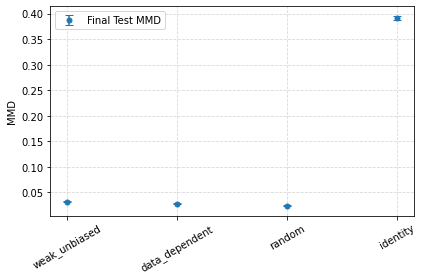

In [96]:
x = np.arange(len(methods_list))
plt.figure()

plt.errorbar(x,means,yerr=stds,fmt='o',markersize=5,capsize=4,label='Final Test MMD')
plt.xticks(x, methods_list, rotation=30)
plt.ylabel("MMD")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# To compare kernels

In [ ]:
#choose your ansatz 
ansatz = "haar"

#choose your initialization strategy
#options: weak_unbiased, identity, random, data_dependent, pairwise_uniform, block_uniform
initialization = "weak_unbiased"
master_key = jax.random.PRNGKey(0)

In [98]:
# parameter useful for data_baised kernel and weighted gaussian
epsilon = 1e-3
mode_probs_train = jnp.mean(X_train, axis=0) + epsilon
mode_probs_train = mode_probs_train / jnp.sum(mode_probs_train)

In [99]:
# Kernels to compare

kernel_configs = {
    
      "polynomial_1": {
        "kernel_type": "polynomial_1",
        "sigma": 0.0,  # unused but we need it as an argument for the function
        "degree": 2,
        "c": 15.5,
        "max_weight": 2,
    },

      "polynomial_2": {
        "kernel_type": "polynomial_2",
        "sigma": 0.0,  # unused also
        "degree": 2,
        "c": 15.5,
        "max_weight": 2,
    },
    
    "gaussian": {
        "kernel_type": "gaussian",
        "sigma": 2.5,
        "degree": 2,
        "c": 1.0,
        "max_weight": 2,
    },
    
    "weighted_gaussian": {
        "kernel_type": "weighted_gaussian",
        "sigma":  2.5,
        "degree": 2,
         "c": 1.0,
         "max_weight": 2,
    },
  
    "low_order": {
        "kernel_type": "low_order",
        "sigma": 0.0,  # unused also
        "degree": 2,
        "c": 1.0,
        "max_weight": 2,
    },

    "data_biased_low_order": {
        "kernel_type": "data_biased_low_order",
        "sigma": 0.0,  # unused
        "degree": 2,
        "c": 1.0,
        "max_weight": 2,
    },
}

## Helper functions

In [ ]:
def run_training_for_kernel(params_init,X_train,X_test,kernel_config,mode_probs_train,m,n,stepsize,n_iters,n_samples_operators,n_samples_gurvits,init_state_ind,key):
    
    key_train, key_test_init, key_test_final = jax.random.split(key, 3)

    def loss_fn(
        params,
        target_dataset,
        sigma,
        m,
        n,
        key,
        n_samples_operators,
        n_samples_gurvits,
        init_state_ind,
        mode_probs,
        kernel_type,
        degree,
        c,
        max_weight,
    ):
        # adapt the function here to you ansatz: MMD_loss_clements_general, MMD_loss_butterfly_general, MMD_loss_mzi3_general
        return MMD_loss_haar_general(
            params=params,
            target_dataset=target_dataset,
            sigma=sigma,
            m=m,
            n=n,
            key=key,
            n_samples_operators=n_samples_operators,
            n_samples_gurvits=n_samples_gurvits,
            init_state_ind=init_state_ind,
            mode_probs=mode_probs,
            kernel_type=kernel_type,
            degree=degree,
            c=c,
            max_weight=max_weight,
        )

    init_test_loss = float(
        loss_fn(
            params=params_init,
            target_dataset=X_test,
            sigma=kernel_config["sigma"],
            m=m,
            n=n,
            key=key_test_init,
            n_samples_operators=n_samples_operators,
            n_samples_gurvits=n_samples_gurvits,
            init_state_ind=init_state_ind,
            mode_probs=mode_probs_train,
            kernel_type=kernel_config["kernel_type"],
            degree=kernel_config["degree"],
            c=kernel_config["c"],
            max_weight=kernel_config["max_weight"],
        )
    )

    loss_kwargs = {
        "params": params_init,
        "target_dataset": X_train,
        "sigma": kernel_config["sigma"],
        "m": m,
        "n": n,
        "key": key_train,
        "n_samples_operators": n_samples_operators,
        "n_samples_gurvits": n_samples_gurvits,
        "init_state_ind": init_state_ind,
        "mode_probs": mode_probs_train,
        "kernel_type": kernel_config["kernel_type"],
        "degree": kernel_config["degree"],
        "c": kernel_config["c"],
        "max_weight": kernel_config["max_weight"],
    }

    trainer = Trainer(
        optimizer,
        loss_fn,
        stepsize,
        opt_jit=False,
    )

    trainer.train(
        n_iters,
        loss_kwargs,
        val_kwargs=None,
        monitor_interval=None,
        turbo=None,
        convergence_interval=200,
    )

    trained_params = jnp.array(trainer.final_params)

    final_test_loss = float(
        loss_fn(
            params=trained_params,
            target_dataset=X_test,
            sigma=kernel_config["sigma"],
            m=m,
            n=n,
            key=key_test_final,
            n_samples_operators=n_samples_operators,
            n_samples_gurvits=n_samples_gurvits,
            init_state_ind=init_state_ind,
            mode_probs=mode_probs_train,
            kernel_type=kernel_config["kernel_type"],
            degree=kernel_config["degree"],
            c=kernel_config["c"],
            max_weight=kernel_config["max_weight"],
        )
    )

    return {
        "trained_params": trained_params,
        "train_curve": np.array(trainer.losses),
        "init_test_loss": init_test_loss,
        "final_train_loss": float(trainer.losses[-1]),
        "final_test_loss": final_test_loss,
    }

In [ ]:
@jax.jit
def dataset_expectations(K, dataset):
    parity = (dataset @ K.T) % 2.0
    values = 1.0 - 2.0 * parity
    return jnp.mean(values, axis=0)


@partial(jax.jit, static_argnames=("m", "n", "n_samples_operators", "kernel_type", "degree", "max_weight"))
def classical_kernel_mmd(model_dataset,target_dataset,sigma,m,n,key,n_samples_operators,mode_probs,kernel_type="gaussian",degree=2,c=1.0,max_weight=2):
    K = sample_kernel_operators(key=key,sigma=sigma,mode_probs=mode_probs,m=m,n=n,n_samples_operators=n_samples_operators,kernel_type=kernel_type,degree=degree,c=c,max_weight=max_weight)
    model_expectations = dataset_expectations(K, model_dataset.astype(jnp.float64))
    target_expectations = dataset_expectations(K, target_dataset.astype(jnp.float64))
    return jnp.real(jnp.mean((model_expectations - target_expectations) ** 2))

## Training

In [ ]:
#to save results
kernel_results_dir = "saved_results"
os.makedirs(kernel_results_dir, exist_ok=True)

for filename in os.listdir(kernel_results_dir):
    if filename.endswith(".tmp"):
        os.remove(os.path.join(kernel_results_dir, filename))

                
n_seeds = 5
results = {}

for kernel_id, (kernel_name, config) in enumerate(kernel_configs.items()):

    print(f"Kernel: {kernel_name}")

    results[kernel_name] = []

    for seed in range(n_seeds):

        result_filename = (
            f"kernel_{kernel_name}_"
            f"ansatz_{ansatz}_"
            f"seed_{seed}_2.pkl"
        )

        result_path = os.path.join(kernel_results_dir, result_filename)

        # if the result exists already we don't repeat the training
        if os.path.exists(result_path):
            print(f"Already done: {result_filename}")

            with open(result_path, "rb") as f:
                result = pickle.load(f)

            results[kernel_name].append(result)
            continue

        print(f"\nRunning | kernel={kernel_name} | ansatz={ansatz} | seed={seed}")
        try:
            key_seed = jax.random.fold_in(master_key, 1000 * kernel_id + seed)
            key_init_seed, key_train_seed, key_random_mmd = jax.random.split(key_seed, 3)

            params, gammas = get_initial_params(method=initialization,ansatz=ansatz,m=m,n=n,key=key_init_seed,X_train=X_train,init_state_ind=init_state_ind,n_pairs=n_pairs,block_sizes=block_sizes)
            params_init_seed = prepare_params_for_loss(params, gammas, ansatz)

            result = run_training_for_kernel(
                params_init=params_init_seed,
                X_train=X_train,
                X_test=X_test,
                kernel_config=config,
                mode_probs_train=mode_probs_train,
                m=m,
                n=n,
                stepsize=stepsize,
                n_iters=n_iters,
                n_samples_operators=n_samples_operators,
                n_samples_gurvits=n_samples_gurvits,
                init_state_ind=init_state_ind,
                key=key_train_seed,
            )

            X_random = random_bitstrings_fixed_weight(
                num_samples=X_test.shape[0],
                m=m,
                n=n,
                seed=1000 * kernel_id + seed,
            )

            random_test_loss =  classical_kernel_mmd(
                model_dataset=X_random,
                target_dataset=X_test,
                sigma=config["sigma"],
                m=m,
                n=n,
                key=key_random_mmd,
                n_samples_operators=n_samples_operators,
                mode_probs=mode_probs_train,
                kernel_type=config["kernel_type"],
                degree=config.get("degree", 2),
                c=config.get("c", 1.0),
                max_weight=config.get("max_weight", 2),
            )

            random_test_loss = float(random_test_loss)

            result["kernel_name"] = kernel_name
            result["kernel_config"] = config
            result["ansatz"] = ansatz
            result["seed"] = seed
            result["random_test_loss"] = random_test_loss
            result["ratio_qcbm_over_random"] = (
                result["final_test_loss"] / random_test_loss
            )

            tmp_path = result_path + ".tmp"

            with open(tmp_path, "wb") as f:
                pickle.dump(result, f)

            os.replace(tmp_path, result_path)

            results[kernel_name].append(result)

            print("Saved:", result_filename)
            print("Final QCBM test MMD:", result["final_test_loss"])
            print("Random baseline MMD:", result["random_test_loss"])
            print("Ratio:", result["ratio_qcbm_over_random"])

        except Exception as e:
            print(
                f"FAILED | kernel={kernel_name} | ansatz={ansatz} | seed={seed}"
            )
            print("Error:", repr(e))

Kernel: polynomial_1

Running | kernel=polynomial_1 | ansatz=haar | seed=0


Training Progress: 100%|██████████| 2/2 [00:04<00:00,  2.18s/it, loss=0.044944, elapsed time=1.15, total time=6.08]


Training has not converged after 2 steps
Saved: kernel_polynomial_1_ansatz_haar_seed_0_2.pkl
Final QCBM test MMD: 0.04083296571537893
Random baseline MMD: 0.040557676
Ratio: 1.0067876106949256

Running | kernel=polynomial_1 | ansatz=haar | seed=1


Training Progress: 100%|██████████| 2/2 [00:02<00:00,  1.17s/it, loss=0.040926, elapsed time=1.17, total time=2.64]


Training has not converged after 2 steps
Saved: kernel_polynomial_1_ansatz_haar_seed_1_2.pkl
Final QCBM test MMD: 0.04017430062488113
Random baseline MMD: 0.04439394666666666
Ratio: 0.9049499682137099

Running | kernel=polynomial_1 | ansatz=haar | seed=2


...

Training has not converged after 2 steps
Saved: kernel_data_biased_low_order_ansatz_haar_seed_2_2.pkl
Final QCBM test MMD: 0.07102201982757929
Random baseline MMD: 0.073045186
Ratio: 0.9723025392471352

Running | kernel=data_biased_low_order | ansatz=haar | seed=3


Training Progress: 100%|██████████| 2/2 [00:02<00:00,  1.21s/it, loss=0.087488, elapsed time=1.16, total time=2.7] 


Training has not converged after 2 steps
Saved: kernel_data_biased_low_order_ansatz_haar_seed_3_2.pkl
Final QCBM test MMD: 0.07714621329415686
Random baseline MMD: 0.06772237333333334
Ratio: 1.1391540121377444

Running | kernel=data_biased_low_order | ansatz=haar | seed=4


Training Progress: 100%|██████████| 2/2 [00:02<00:00,  1.18s/it, loss=0.081628, elapsed time=1.15, total time=2.65]


Training has not converged after 2 steps
Saved: kernel_data_biased_low_order_ansatz_haar_seed_4_2.pkl
Final QCBM test MMD: 0.07804420309987162
Random baseline MMD: 0.07121900466666667
Ratio: 1.0958339486089366


## Graph of compararaison with random baseline

In [ ]:
figures_dir = "figures"
os.makedirs(figures_dir, exist_ok=True)

results_clean = {
    kernel_name: runs
    for kernel_name, runs in results.items()
    if len(runs) > 0
}

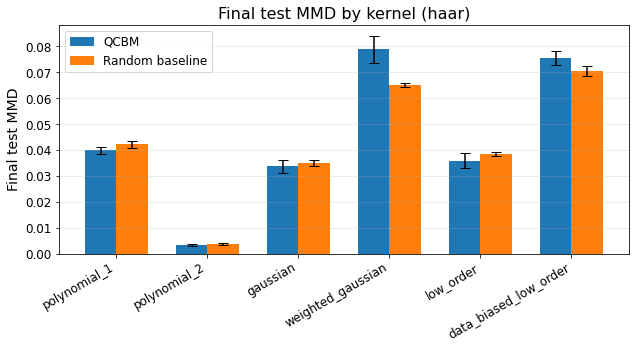

In [108]:
kernel_names = list(results_clean.keys())

qcbm_means = []
qcbm_stds = []

random_means = []
random_stds = []

for kernel_name in kernel_names:
    kernel_runs = results_clean[kernel_name]

    qcbm_values = np.array([res["final_test_loss"] for res in kernel_runs], dtype=float)
    random_values = np.array([res["random_test_loss"] for res in kernel_runs], dtype=float)

    qcbm_means.append(np.mean(qcbm_values))
    qcbm_stds.append(np.std(qcbm_values))

    random_means.append(np.mean(random_values))
    random_stds.append(np.std(random_values))

x = np.arange(len(kernel_names))
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(
    x - width / 2,
    qcbm_means,
    width,
    yerr=qcbm_stds,
    capsize=5,
    label="QCBM",
)

plt.bar(
    x + width / 2,
    random_means,
    width,
    yerr=random_stds,
    capsize=5,
    label="Random baseline",
)

plt.xticks(x, kernel_names, rotation=30, ha="right")
plt.ylabel("Final test MMD")
plt.title(f"Final test MMD by kernel ({ansatz})")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(os.path.join(figures_dir, f"final_test_mmd_kernels_{ansatz}.pdf"))
plt.savefig(os.path.join(figures_dir, f"final_test_mmd_kernels_{ansatz}.png"), dpi=300)

plt.show()

### Please note that the demo is set to only 2 iterations per optimization so it can be run fast as an example. This is why we see values of the MMD so close to the random benchmark in the above figure.